In [437]:
from cProfile import label

import matplotlib.pyplot as plt

import numpy as np
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import figure
from pandas.core import flags

In [438]:
X  = np.array([40, 55, 70, 80, 95, 110], dtype=float)

y = np.array([220000, 360000, 400000, 470000, 620000, 740000], dtype=float)

print(X)
print(y)

[ 40.  55.  70.  80.  95. 110.]
[220000. 360000. 400000. 470000. 620000. 740000.]


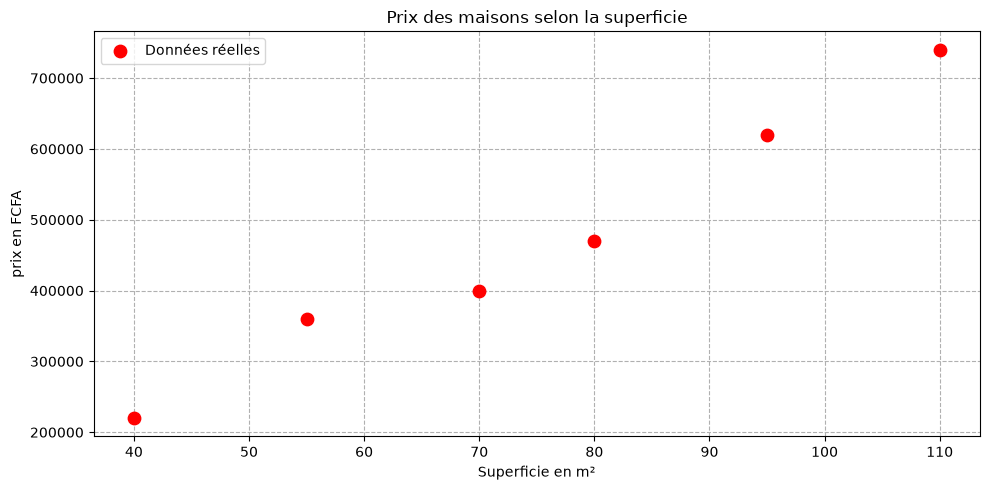

In [439]:
plt.figure(figsize=(10, 5))
plt.scatter(
    X,
    y,
    color="red",
    s=80,
    zorder=5,
    label= "Données réelles",
)

plt.xlabel("Superficie en m²")
plt.ylabel("prix en FCFA")
plt.title('Prix des maisons selon la superficie')
plt.legend()
plt.grid(linestyle="--")
plt.tight_layout()
plt.show()


normalisation des données


In [440]:
X_moyenne = X.mean()
x_ecart_type = X.std()

x_norm = (X - X_moyenne) / x_ecart_type



print(x_ecart_type)

23.45207879911715


Initialisation des données

In [441]:
np.random.seed(42)

w = np.random.randn() * 0.01

b= 0.0
learning_rate = 0.1

n_epoques = 200

n = len(x_norm)

y_milliers = y/1000

print(f"valeur initiale de w: {w:.6f}")
print(f"valuer initiale de b: {b:.6f}")


valeur initiale de w: 0.004967
valuer initiale de b: 0.000000


on va essayer de visualiser les données, pardon!!!! l'historique des données !!

In [442]:
historique_perte = []
historique_w = []
historique_b = []

In [443]:
for elem in range(n_epoques):
    y_pred = w * x_norm + b

    erreur_quadratique_moyenne = y_pred - y_milliers

    perte = (1/n) * np.sum(erreur_quadratique_moyenne) **2


    gradient_w= (2 / n) * np.sum(erreur_quadratique_moyenne * x_norm)
    gradient_b = (2 / n) * np.sum(erreur_quadratique_moyenne)

    w= w - learning_rate * gradient_w
    b = b - learning_rate * gradient_b

    #Mémoriser les valeurs de cette époque

    historique_b.append(b)
    historique_perte.append(perte)
    historique_w.append(w)



Visualisons la courbe de perte

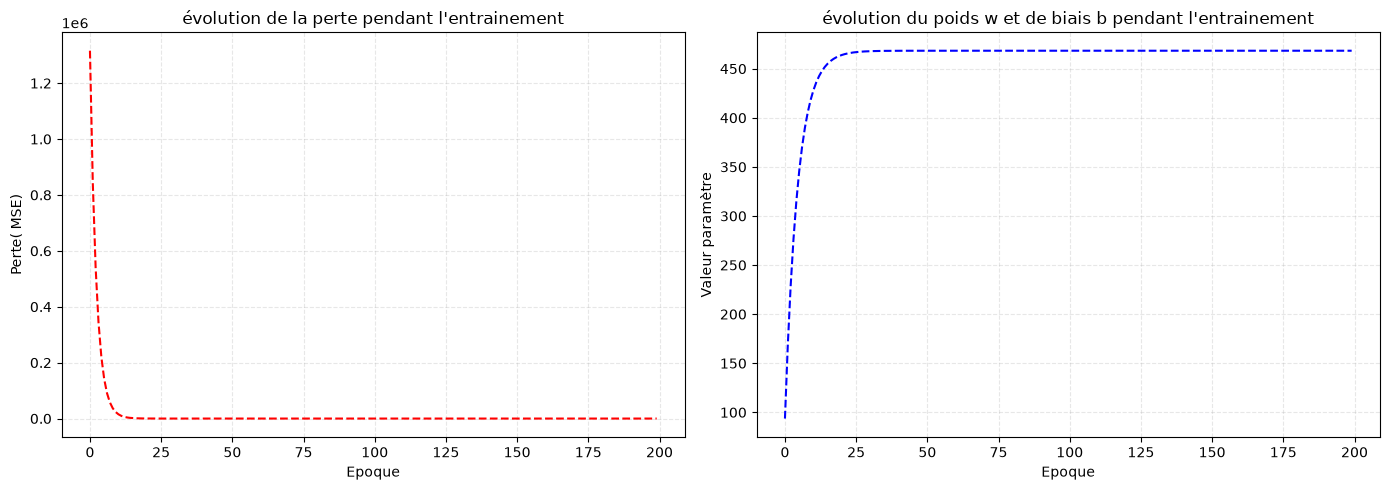

In [444]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historique_perte, color='red', linestyle='--')

axes[0].set_ylabel("Perte( MSE)")

axes[0].set_xlabel("Epoque")
axes[0].set_title("évolution de la perte pendant l'entrainement")
axes[0].grid(linestyle="--", alpha=0.3)


axes[1].set_xlabel("Epoque")
axes[1].set_ylabel("Valeur paramètre")
axes[1].plot(historique_b, color='blue', linestyle='--')
axes[1].set_title("évolution du poids w et de biais b pendant l'entrainement")
axes[1].grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


visualisons la droite apprise

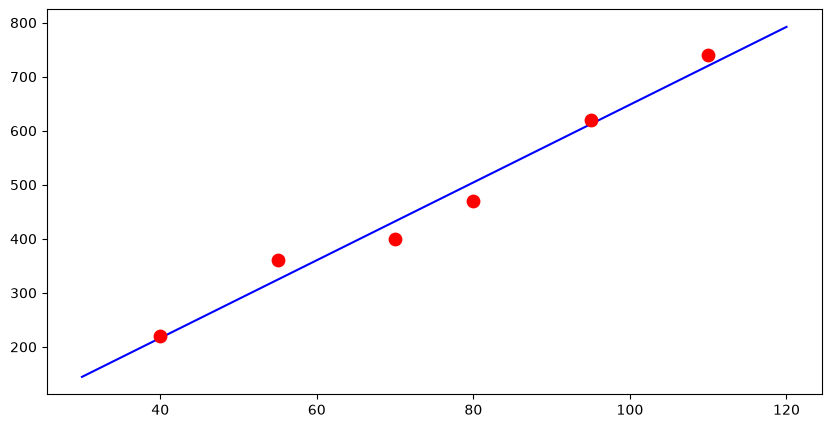

In [445]:
plt.figure(figsize=(10, 5))

plt.scatter(X, y_milliers, color="red", s=80, zorder=5, label='Données réélles')
#traçons une droite, l'idée serai de générer des points tellement serrées qu'on dirait une droite


x_line  = np.linspace(30, 120, 200)

x_line_norm = (x_line - X_moyenne) / x_ecart_type
y_line = w * x_line_norm + b

plt.plot(x_line, y_line, color='blue', linestyle='-')
plt.show()

on va essayer de faire quelques prédictions maintenant

In [456]:
def predict(surface, w, b, x_moyenne, x_ecart_type):

    x_normalise = (surface - x_moyenne) / x_ecart_type
    price = w * x_normalise + b

    return price


print('prédictions')
print()

print(f'{'surface'}       {"prix prédit"}        {"note"}  ')


for superficie in  [32, 11, 55, 80, 140]:
    prix = predict(superficie, w, b, X_moyenne, x_ecart_type)

    if superficie <= 110:
        note = "Dans la plage de données"
    else:
        note = "extrapolation !!!!!!!!" #c'est juste une note pour préciser que les valeur peuvent être fausses
print(superficie, "m²",'\t', '\t',  prix.round() * 1000, "FCFA", '\t', note   )

prédictions

surface       prix prédit        note  
140 m² 	 	 936000.0 FCFA 	 extrapolation !!!!!!!!


on va refaire la même chose mais avec sckit-learn

In [447]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


In [448]:
X_sk = X.reshape(-1, 1)
y_sk = y

X_sk

array([[ 40.],
       [ 55.],
       [ 70.],
       [ 80.],
       [ 95.],
       [110.]])

In [449]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sk,
    y_sk,
    test_size=0.33,
    random_state= 120#j'ai dû twister plusieurs fois au final, la valeur qui me rapprochait le plus de 1.0
    #du coefficient r² est 120, j'avais mis 42, le classique et c'étais un négatif
)

Normalisation des données

In [450]:
normalizer = StandardScaler()
X_train_norm = normalizer.fit_transform(X_train)

X_test_norm = normalizer.fit_transform(X_test)

création d'une instance du modèle linearRegression()

In [451]:
model = LinearRegression()
model.fit(X_train_norm, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


on va voir les paramètres appris

In [452]:
print('poids (w) appris', model.coef_[0])
print('biais (b) appris', model.intercept_)

poids (w) appris 185500.0
biais (b) appris 457500.0


évaluation du modèle

In [453]:
y_pred_test = model.predict(X_test_norm)

MSE = mean_squared_error(y_test, y_pred_test)
R_MSE = np.sqrt(MSE)
r2 = r2_score(y_test, y_pred_test)

print("évaluation sur le test set")
print("MSE: ", MSE)
print("RMSE: ", R_MSE)
print('R²: ', r2)

évaluation sur le test set
MSE:  4136500000.0
RMSE:  64315.62796086189
R²:  0.7552366863905325


In [455]:
print("prédition et réalité")

print('superficie: ',  '\t', 'prix réél','\t', "prix_prédit", '\t', "Erreur")

for i in  range(len(X_test)):

    superficie = X_test[i][0]
    reel = y_test[i]
    predit = y_pred_test[i]
    erreur = reel - predit

print(superficie, 'm²''\t', '\t', reel, 'FCFA','\t', predit, 'FCFA','\t', erreur, 'FCFA')


prédition et réalité
superficie:  	 prix réél 	 prix_prédit 	 Erreur
95.0 m²	 	 620000.0 FCFA 	 643000.0 FCFA 	 -23000.0 FCFA


C'EST doyi !!!!!!!!!!!!!!!!